### Loading the cleaned master dataset

In [1]:
import pandas as pd

master_clean = pd.read_csv(
    "../data/processed/master_clean.csv",
    parse_dates=["utc_timestamp", "time"]
)

master_clean.head()

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,time,temperature_C,humidity_pct,...,wind_speed_ms,precipitation_mm,hour,day_of_week,month,year,is_weekend,quarter,week_of_year,season
0,2015-01-01 00:00:00+00:00,41151.0,71.0,8852.0,37248.0,27913.0,NaN,2015-01-01 00:00:00+00:00,0.96,94.4,...,8.50,0.0,0,3,1,2015,0,1,1,Winter
1,2015-01-01 01:00:00+00:00,40135.0,71.0,9054.0,37248.0,27913.0,NaN,2015-01-01 01:00:00+00:00,0.62,94.4,...,8.72,0.0,1,3,1,2015,0,1,1,Winter
2,2015-01-01 02:00:00+00:00,39106.0,71.0,9070.0,37248.0,27913.0,NaN,2015-01-01 02:00:00+00:00,0.44,94.0,...,8.84,0.0,2,3,1,2015,0,1,1,Winter
3,2015-01-01 03:00:00+00:00,38765.0,71.0,9163.0,37248.0,27913.0,NaN,2015-01-01 03:00:00+00:00,0.42,94.2,...,8.52,0.0,3,3,1,2015,0,1,1,Winter
4,2015-01-01 04:00:00+00:00,38941.0,71.0,9231.0,37248.0,27913.0,NaN,2015-01-01 04:00:00+00:00,0.18,94.2,...,9.34,0.0,4,3,1,2015,0,1,1,Winter


### Creating a working copy of the cleaned master dataset

In [2]:
eda_df = master_clean.copy()

print(eda_df.shape)

(50400, 21)


### Creating a correlation analysis dataset

In [3]:
corr_data = eda_df[
    [
        'DE_load_actual_entsoe_transparency',
        'DE_solar_generation_actual',
        'DE_wind_generation_actual',
        'temperature_C',
        'humidity_pct',
        'cloud_cover_pct',
        'wind_speed_ms',
        'precipitation_mm'
    ]
]

corr_data.head()

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
0,41151.0,71.0,8852.0,0.96,94.4,67.4,8.50,0.0
1,40135.0,71.0,9054.0,0.62,94.4,67.8,8.72,0.0
2,39106.0,71.0,9070.0,0.44,94.0,71.0,8.84,0.0
3,38765.0,71.0,9163.0,0.42,94.2,79.2,8.52,0.0
4,38941.0,71.0,9231.0,0.18,94.2,83.6,9.34,0.0


### Calculating the correlation matrix

In [4]:
corr_matrix = corr_data.corr(
    numeric_only=True
)

corr_matrix

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
DE_load_actual_entsoe_transparency,1.000000,0.312084,0.103683,-0.069806,-0.178599,0.141674,0.198945,0.036542
DE_solar_generation_actual,0.312084,1.000000,-0.174922,0.485171,-0.644211,-0.136355,0.011728,-0.057361
DE_wind_generation_actual,0.103683,-0.174922,1.000000,-0.234537,0.043040,0.191692,0.847792,0.192887
temperature_C,-0.069806,0.485171,-0.234537,1.000000,-0.612602,-0.157135,-0.125287,0.043460
humidity_pct,-0.178599,-0.644211,0.043040,-0.612602,1.000000,0.255056,-0.097553,0.124840
cloud_cover_pct,0.141674,-0.136355,0.191692,-0.157135,0.255056,1.000000,0.254857,0.329252
wind_speed_ms,0.198945,0.011728,0.847792,-0.125287,-0.097553,0.254857,1.000000,0.285694
precipitation_mm,0.036542,-0.057361,0.192887,0.043460,0.124840,0.329252,0.285694,1.000000


### Focusing on demand correlations only

In [5]:
corr_matrix[
    'DE_load_actual_entsoe_transparency'
].sort_values(
    ascending=False
)

DE_load_actual_entsoe_transparency    1.000000
DE_solar_generation_actual            0.312084
wind_speed_ms                         0.198945
cloud_cover_pct                       0.141674
DE_wind_generation_actual             0.103683
precipitation_mm                      0.036542
temperature_C                        -0.069806
humidity_pct                         -0.178599
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing Demand vs Temperature

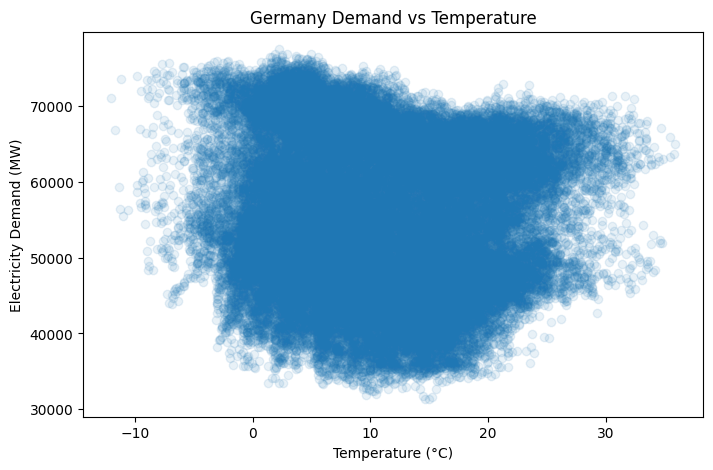

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['temperature_C'],
    eda_df['DE_load_actual_entsoe_transparency'],
    alpha=0.1
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Electricity Demand (MW)')
plt.title('Germany Demand vs Temperature')

plt.show()

*Germany electricity demand exhibits only a weak linear relationship with temperature (r = −0.07). Scatter plot analysis shows substantial variability in demand across all temperature ranges, indicating that temporal and socio-economic factors likely play a larger role than temperature alone.*

### Creating a cleaner view using average demand by temperature

In [7]:
temp_analysis = (
    eda_df
    .groupby('temperature_C')
    ['DE_load_actual_entsoe_transparency']
    .mean()
)

temp_analysis.head()

temperature_C
-12.04    71155.0
-11.76    66897.0
-11.42    59332.0
-11.32    56418.0
-11.18    73604.0
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Plotting average demand vs temperature

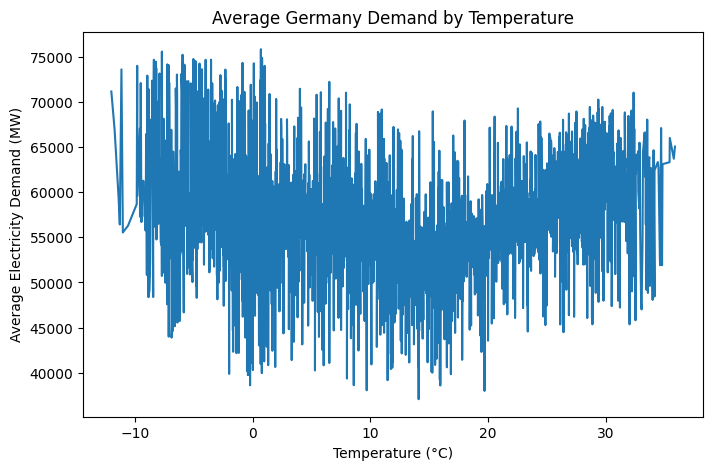

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    temp_analysis.index,
    temp_analysis.values
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Average Electricity Demand (MW)')
plt.title('Average Germany Demand by Temperature')

plt.show()

*Although the linear correlation between temperature and electricity demand was weak (r = −0.07), aggregation revealed a V-shaped relationship, indicating that demand increases during both cold and hot conditions. This suggests a non-linear temperature effect on electricity consumption.*

### Analyze Demand vs Wind Generation

In [9]:
wind_corr = corr_matrix[
    'DE_load_actual_entsoe_transparency'
]['DE_wind_generation_actual']

print(wind_corr)

0.10368320616882883


*Periods with higher wind generation tend to have slightly higher electricity demand, but the relationship is weak.*

*This is not surprising because:*

*Wind generation depends primarily on weather.*   
*Electricity demand depends primarily on human activity and time patterns.*   
*Wind generation does not cause demand; it only helps meet it.*

### Visualizing Demand vs Wind Generation

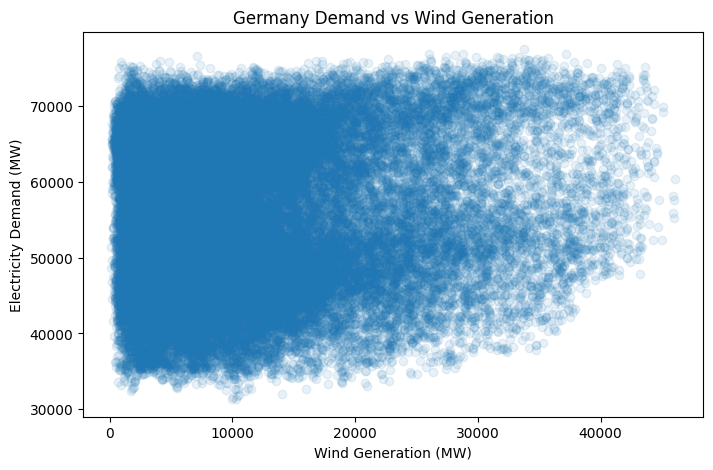

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['DE_wind_generation_actual'],
    eda_df['DE_load_actual_entsoe_transparency'],
    alpha=0.1
)

plt.xlabel('Wind Generation (MW)')
plt.ylabel('Electricity Demand (MW)')
plt.title('Germany Demand vs Wind Generation')

plt.show()

High wind generation can occur during periods of both low and high demand. Therefore, wind availability alone is not a strong predictor of electricity consumption.

*Wind generation contains some information, but it is not a dominant driver of demand.*

### Creating a clearer wind analysis

*Instead of looking at 50,000 points, let's average demand by wind-generation level.*

In [11]:
wind_bins = pd.cut(
    eda_df['DE_wind_generation_actual'],
    bins=20
)

wind_analysis = (
    eda_df
    .groupby(wind_bins)['DE_load_actual_entsoe_transparency']
    .mean()
)

wind_analysis.head()

DE_wind_generation_actual
(89.071, 2431.45]     56330.804016
(2431.45, 4727.9]     54359.979253
(4727.9, 7024.35]     54509.388962
(7024.35, 9320.8]     54723.358113
(9320.8, 11617.25]    54901.745943
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing average demand by wind generation level

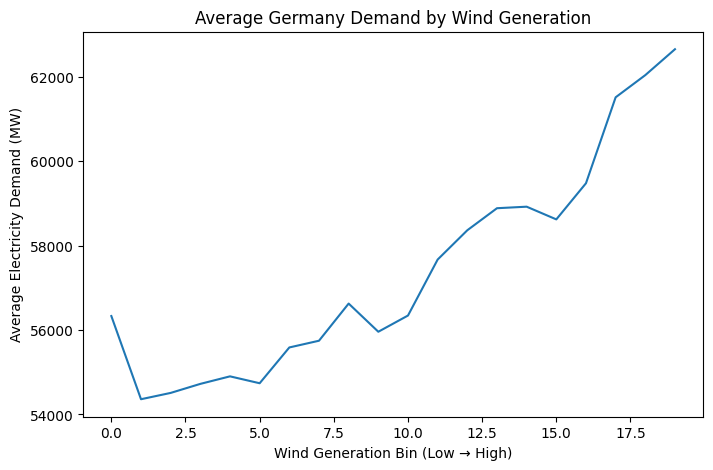

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(len(wind_analysis)),
    wind_analysis.values
)

plt.xlabel('Wind Generation Bin (Low → High)')
plt.ylabel('Average Electricity Demand (MW)')
plt.title('Average Germany Demand by Wind Generation')

plt.show()

*While the direct correlation between wind generation and demand was weak (r = 0.104), binning analysis revealed a gradual increase in average demand with increasing wind generation. This suggests a shared seasonal influence rather than a direct causal relationship.*

### Analyzing Demand vs Solar Generation

In [13]:
solar_corr = corr_matrix[
    'DE_load_actual_entsoe_transparency'
]['DE_solar_generation_actual']

print(solar_corr)

0.31208399210028964


### Visualizing Demand vs Solar Generation

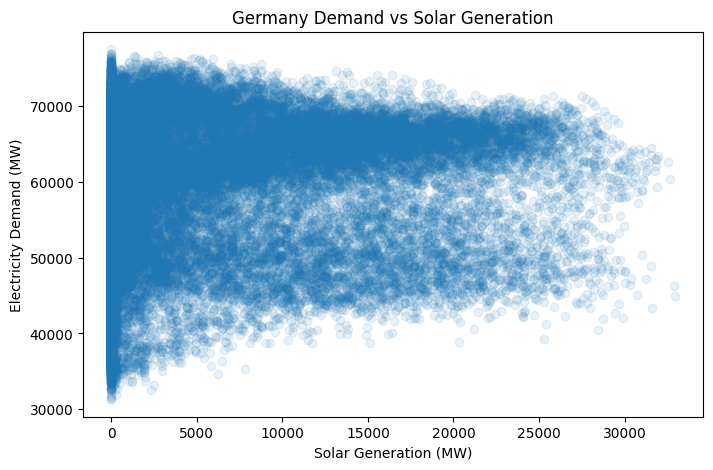

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['DE_solar_generation_actual'],
    eda_df['DE_load_actual_entsoe_transparency'],
    alpha=0.1
)

plt.xlabel('Solar Generation (MW)')
plt.ylabel('Electricity Demand (MW)')
plt.title('Germany Demand vs Solar Generation')

plt.show()

### Creating a clearer solar generation analysis

In [15]:
solar_bins = pd.cut(
    eda_df['DE_solar_generation_actual'],
    bins=20
)

solar_analysis = (
    eda_df
    .groupby(solar_bins)['DE_load_actual_entsoe_transparency']
    .mean()
)

solar_analysis.head()

DE_solar_generation_actual
(-32.947, 1647.35]    52084.962814
(1647.35, 3294.7]     60058.208067
(3294.7, 4942.05]     60742.477568
(4942.05, 6589.4]     60919.087525
(6589.4, 8236.75]     60408.925793
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing Average Demand by Solar Generation

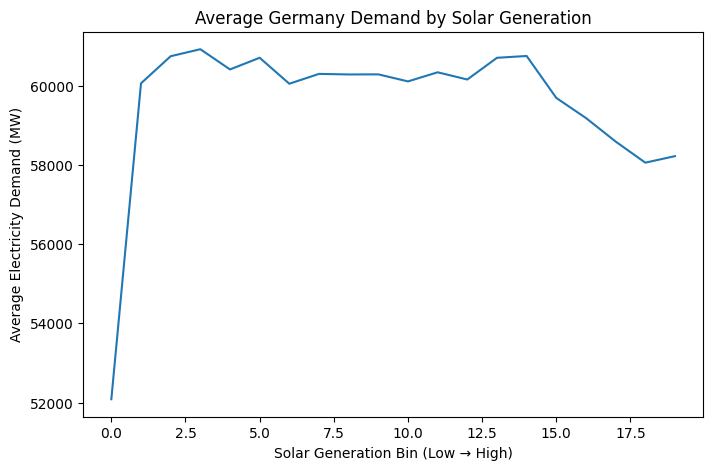

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(len(solar_analysis)),
    solar_analysis.values
)

plt.xlabel('Solar Generation Bin (Low → High)')
plt.ylabel('Average Electricity Demand (MW)')
plt.title('Average Germany Demand by Solar Generation')

plt.show()

### Weekend vs Weekday Demand

In [17]:
eda_df.groupby(
    'is_weekend'
)['DE_load_actual_entsoe_transparency'].mean()

is_weekend
0    58585.116972
1    47760.847500
Name: DE_load_actual_entsoe_transparency, dtype: float64

*Germany's average electricity demand is approximately 18.5% lower on weekends than on weekdays.*
*This suggests that:*

*Industrial and commercial activities are major contributors to Germany's electricity demand.*  
*Human behavior and economic activity may be more important demand drivers than weather alone.*  
*Calendar features (hour, weekday, weekend) are likely to be very valuable for forecasting models.*

### Visualizing Weekend vs Weekday Demand

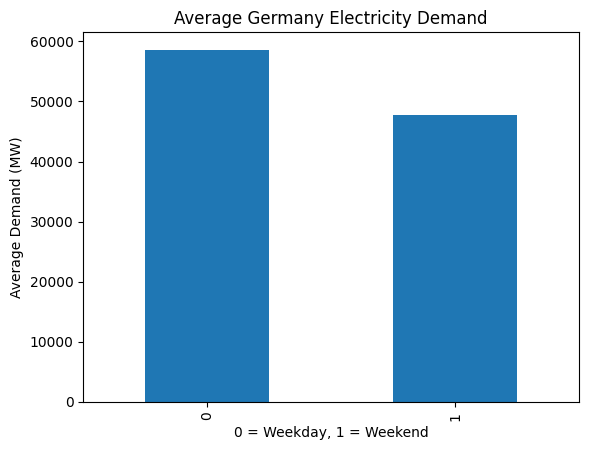

In [18]:
eda_df.groupby(
    'is_weekend'
)['DE_load_actual_entsoe_transparency'].mean().plot(
    kind='bar'
)

plt.title('Average Germany Electricity Demand')
plt.xlabel('0 = Weekday, 1 = Weekend')
plt.ylabel('Average Demand (MW)')

plt.show()

### Analyzing Seasonal Demand Patterns

In [19]:
eda_df.groupby(
    'season'
)['DE_load_actual_entsoe_transparency'].mean().sort_values(
    ascending=False
)

season
Winter    58834.343852
Autumn    56026.780069
Spring    54379.230752
Summer    53042.591561
Name: DE_load_actual_entsoe_transparency, dtype: float64

*Germany shows a clear seasonal pattern:*  

*Winter > Autumn > Spring > Summer*    
*Germany's average electricity demand is approximately 11% higher in winter than in summer.*

This supports what we observed earlier:

Germany appears to be more heating-driven than cooling-driven.  
Seasonal effects are stronger than the simple temperature correlation suggested.  
Winter demand is elevated due to lighting, heating, and increased energy consumption during colder months.

*This strongly suggests that calendar features (hour, day_of_week, month, season, is_weekend) will be very important predictors in future forecasting models.*

### Analyzing Hourly Demand Patterns

In [20]:
hourly_demand = (
    eda_df.groupby('hour')
    ['DE_load_actual_entsoe_transparency']
    .mean()
)

hourly_demand

hour
0     43882.047619
1     43553.034762
2     44133.652381
3     45950.040952
4     50131.535238
5     55042.064762
6     58897.579048
7     60921.150000
8     62353.457143
9     63640.790952
10    63733.839048
11    62800.928095
12    61518.203810
13    60384.280000
14    59498.595714
15    59598.973810
16    60662.533333
17    60974.783333
18    59544.625238
19    56794.175238
20    54039.865714
21    50915.867143
22    47596.083810
23    45251.138095
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing the Daily Demand Curve

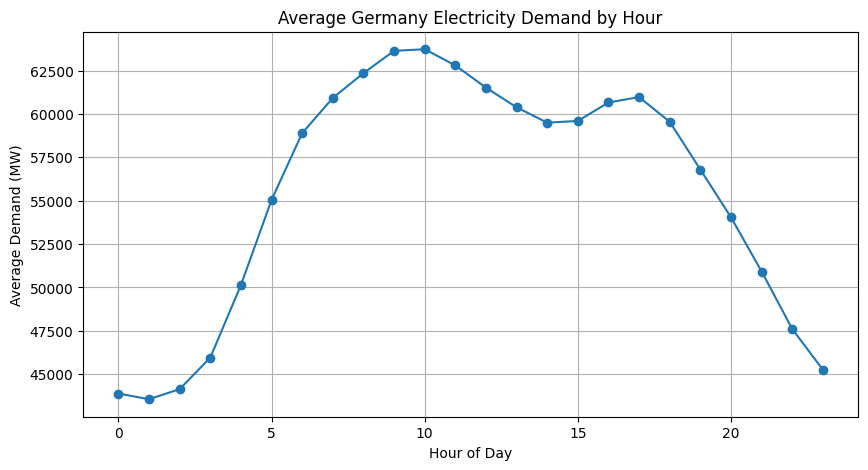

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker='o'
)

plt.title('Average Germany Electricity Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand (MW)')
plt.grid(True)

plt.show()

### Monthly Demand Patterns

In [22]:
monthly_demand = (
    eda_df.groupby('month')
    ['DE_load_actual_entsoe_transparency']
    .mean()
)

monthly_demand

month
1     59446.345430
2     59974.808088
3     57605.863127
4     53208.974769
5     52285.104167
6     53111.104630
7     53452.633961
8     52566.246192
9     53705.266667
10    55620.674194
11    59232.238889
12    56849.110215
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Visualizing the Annual Demand Cycle

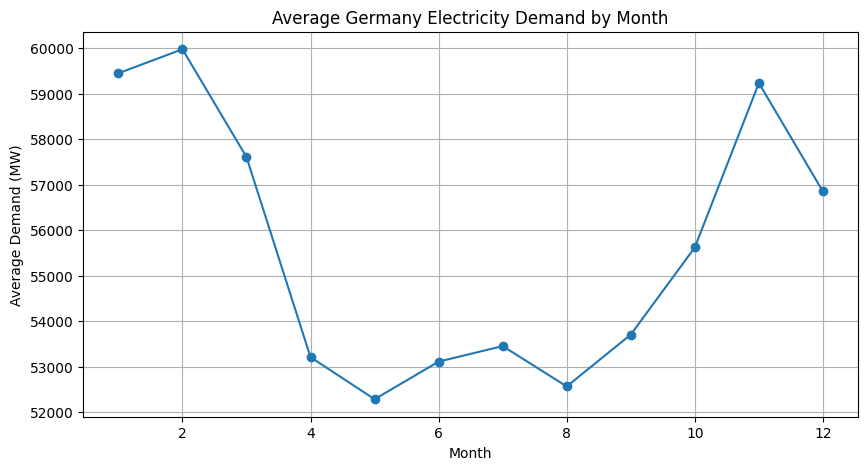

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker='o'
)

plt.title('Average Germany Electricity Demand by Month')
plt.xlabel('Month')
plt.ylabel('Average Demand (MW)')
plt.grid(True)

plt.show()

Germany's demand is influenced by more than weather:

Industrial activity  
Public holidays  
Vacation periods  
School schedules  
Business cycles  

The December drop is especially interesting because it supports the idea that:

Economic activity can outweigh pure weather effects.

### Renewable Generation Patterns
#### Investigating how solar generation behaves through the year and whether it aligns with demand patterns.

In [24]:
monthly_solar = (
    eda_df.groupby('month')
    ['DE_solar_generation_actual']
    .mean()
)

monthly_solar

month
1     1027.163306
2     2382.900980
3     4113.724910
4     6551.908333
5     7034.007841
6     7424.596991
7     7377.520833
8     6682.958333
9     5270.359954
10    2928.388978
11    1446.132222
12     961.200269
Name: DE_solar_generation_actual, dtype: float64

Solar generation appears to be negatively aligned with seasonal demand:

Winter:  
High demand  
Low solar  

Summer:  
Lower demand  
High solar  

This suggests that storage, transmission, imports, or complementary renewable sources (such as wind) become important for balancing the system.

#### Investigating how wind generation behaves through the year and whether it aligns with demand patterns.

In [25]:
monthly_wind = (
    eda_df.groupby('month')
    ['DE_wind_generation_actual']
    .mean()
)

monthly_wind

month
1     16028.606407
2     15656.269118
3     14184.999776
4     10570.977083
5      8961.310520
6      7697.769176
7      7607.631272
8      7339.811380
9      9134.325463
10    11918.028226
11    13587.163333
12    17531.390054
Name: DE_wind_generation_actual, dtype: float64

| Month    | Wind Generation (MW) |
| -------- | -------------------: |
| December |               17,531 |
| January  |               16,029 |
| February |               15,656 |
| July     |                7,608 |
| August   |                7,340 |


#### Comparing all three variables

| Season | Demand | Solar | Wind |
| ------ | ------ | ----- | ---- |
| Winter | High   | Low   | High |
| Summer | Lower  | High  | Low  |


*Seasonal analysis revealed strong complementarity between solar and wind generation. Solar output peaks during summer months when demand is relatively low, whereas wind generation peaks during winter months when demand is highest and solar output is weakest. This complementary behavior supports renewable integration and grid reliability.*

### Visualizing Demand, Solar, and Wind Together

In [26]:
monthly_compare = eda_df.groupby('month')[
    [
        'DE_load_actual_entsoe_transparency',
        'DE_solar_generation_actual',
        'DE_wind_generation_actual'
    ]
].mean()

monthly_compare

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual
month,,,
1,59446.345430,1027.163306,16028.606407
2,59974.808088,2382.900980,15656.269118
3,57605.863127,4113.724910,14184.999776
4,53208.974769,6551.908333,10570.977083
5,52285.104167,7034.007841,8961.310520
6,53111.104630,7424.596991,7697.769176
7,53452.633961,7377.520833,7607.631272
8,52566.246192,6682.958333,7339.811380
9,53705.266667,5270.359954,9134.325463


### Creating the Combined Energy Profile Plot

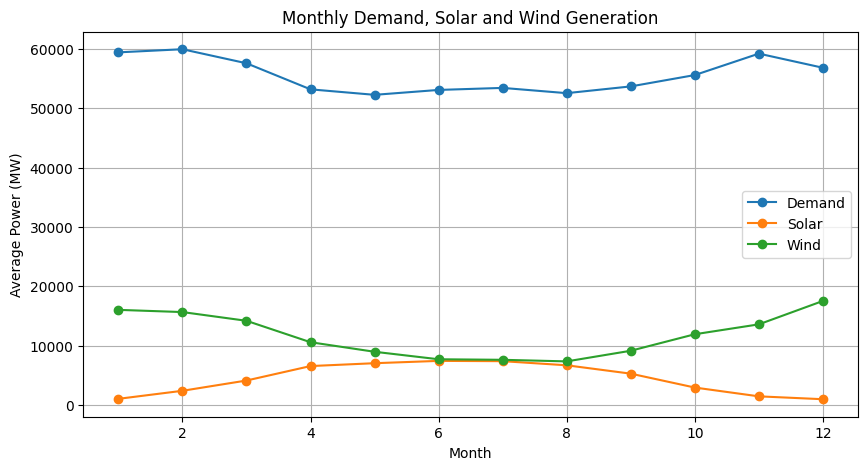

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_compare.index,
    monthly_compare['DE_load_actual_entsoe_transparency'],
    marker='o',
    label='Demand'
)

plt.plot(
    monthly_compare.index,
    monthly_compare['DE_solar_generation_actual'],
    marker='o',
    label='Solar'
)

plt.plot(
    monthly_compare.index,
    monthly_compare['DE_wind_generation_actual'],
    marker='o',
    label='Wind'
)

plt.title('Monthly Demand, Solar and Wind Generation')
plt.xlabel('Month')
plt.ylabel('Average Power (MW)')
plt.legend()
plt.grid(True)

plt.show()

*Monthly analysis revealed strong seasonal complementarity between solar and wind generation. Solar output peaked during summer months (June–July), whereas wind generation peaked during winter months (December–February). Demand patterns aligned more closely with wind generation than solar generation, suggesting that wind plays a particularly important role in meeting Germany's winter electricity needs.*

### Checking Solar vs Cloud Cover Correlation

In [28]:
eda_df[
    [
        'DE_solar_generation_actual',
        'cloud_cover_pct'
    ]
].corr()

,DE_solar_generation_actual,cloud_cover_pct
DE_solar_generation_actual,1.000000,-0.136355
cloud_cover_pct,-0.136355,1.000000


### Solar Generation vs Cloud Cover
The correlation between solar generation and cloud cover was found to be **-0.136**, indicating a weak negative relationship. While increased cloud cover is expected to reduce solar generation, the observed relationship is weaker than anticipated.

A likely explanation is that the analysis includes nighttime observations, during which solar generation is zero regardless of cloud conditions. As a result, the effect of cloud cover on solar output is diluted when considering the full dataset.

To better understand the weather impact on solar generation, the analysis will be repeated using only daylight periods when solar generation is greater than zero.

### Restricting Analysis to Daylight Hours

In [29]:
solar_daylight = eda_df[
    eda_df['DE_solar_generation_actual'] > 0
]

solar_daylight[
    [
        'DE_solar_generation_actual',
        'cloud_cover_pct'
    ]
].corr()

,DE_solar_generation_actual,cloud_cover_pct
DE_solar_generation_actual,1.000000,-0.254871
cloud_cover_pct,-0.254871,1.000000


### Daylight Solar Generation vs Cloud Cover

To better assess the influence of weather on solar generation, nighttime observations were excluded by selecting periods with solar generation greater than zero.

The correlation between solar generation and cloud cover increased from **-0.136** to **-0.255**, indicating a stronger negative relationship during daylight hours. This confirms that cloud cover reduces solar power production, although the relationship remains moderate rather than strong.

The result suggests that solar generation is influenced not only by cloud cover but also by other factors such as time of day, seasonal changes in solar irradiance, and installed solar capacity.

### Visualizing Solar Generation vs Cloud Cover

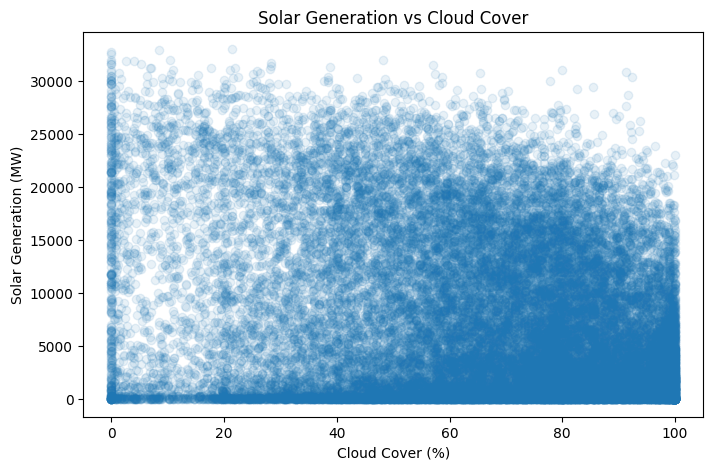

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    solar_daylight['cloud_cover_pct'],
    solar_daylight['DE_solar_generation_actual'],
    alpha=0.1
)

plt.xlabel('Cloud Cover (%)')
plt.ylabel('Solar Generation (MW)')
plt.title('Solar Generation vs Cloud Cover')

plt.show()

### Solar Generation vs Cloud Cover

The scatter plot revealed a clear but highly variable negative relationship between cloud cover and solar generation. While the maximum achievable solar output decreases as cloud cover increases, substantial variability exists across all cloud-cover levels.

The relationship appears triangular rather than linear, indicating that cloud cover constrains the upper limit of solar generation but does not fully determine actual output. Other factors, including time of day, seasonal solar irradiance, and installed solar capacity, also play important roles.

This explains why the daylight-only correlation between solar generation and cloud cover remains moderate (-0.255) despite the expected physical relationship.

### Checking Solar Generation vs Temperature

In [31]:
solar_daylight[
    [
        'DE_solar_generation_actual',
        'temperature_C'
    ]
].corr()

,DE_solar_generation_actual,temperature_C
DE_solar_generation_actual,1.000000,0.468533
temperature_C,0.468533,1.000000


### Solar Generation vs Temperature

The correlation between solar generation and temperature was found to be **0.469**, indicating a moderate positive relationship and a substantially stronger association than observed with cloud cover (-0.255).

Higher temperatures generally coincide with increased solar generation, primarily because temperature acts as a proxy for seasonal conditions such as longer daylight hours and higher solar irradiance. The result suggests that seasonal factors exert a stronger influence on solar generation than cloud cover alone.

It is important to note that temperature does not directly cause increased solar generation; rather, both variables are influenced by underlying seasonal patterns.

### Comparing Weather Drivers of Solar Generation

In [32]:
solar_daylight[
    [
        'DE_solar_generation_actual',
        'temperature_C',
        'humidity_pct',
        'cloud_cover_pct',
        'wind_speed_ms',
        'precipitation_mm'
    ]
].corr()['DE_solar_generation_actual'].sort_values(
    ascending=False
)

DE_solar_generation_actual    1.000000
temperature_C                 0.468533
wind_speed_ms                -0.035385
precipitation_mm             -0.122222
cloud_cover_pct              -0.254871
humidity_pct                 -0.608740
Name: DE_solar_generation_actual, dtype: float64

### Weather Drivers of Solar Generation

Correlation analysis was performed between solar generation and key weather variables during daylight hours. Among the variables considered, humidity exhibited the strongest relationship with solar generation (-0.609), followed by temperature (0.469) and cloud cover (-0.255).

The strong negative correlation with humidity suggests that atmospheric moisture may be a better indicator of solar generation conditions than cloud cover alone. High humidity is frequently associated with cloudy, foggy, or rainy conditions that reduce incoming solar radiation.

Overall, the results indicate that humidity and temperature are the most influential weather-related predictors of solar generation in the dataset, while wind speed and precipitation show relatively weak relationships.

### Starting Wind Analysis

In [33]:
eda_df[
    [
        'DE_wind_generation_actual',
        'temperature_C',
        'humidity_pct',
        'cloud_cover_pct',
        'wind_speed_ms',
        'precipitation_mm'
    ]
].corr()['DE_wind_generation_actual'].sort_values(
    ascending=False
)

DE_wind_generation_actual    1.000000
wind_speed_ms                0.847792
precipitation_mm             0.192887
cloud_cover_pct              0.191692
humidity_pct                 0.043040
temperature_C               -0.234537
Name: DE_wind_generation_actual, dtype: float64

### Weather Drivers of Wind Generation

Correlation analysis revealed that wind speed is the dominant weather driver of wind generation, exhibiting a very strong positive correlation of **0.848**. This relationship is substantially stronger than any weather-related correlation observed for solar generation.

The result is consistent with the physical operation of wind turbines, where increased wind speeds directly increase electricity production. Cloud cover (0.192) and precipitation (0.193) showed weak positive correlations, likely reflecting their association with storm systems and windy weather conditions.

Temperature displayed a moderate negative correlation (-0.235), indicating that wind generation tends to be higher during colder periods of the year. Overall, wind speed emerged as the single strongest weather predictor identified in the dataset.

### Visualizing Wind Generation vs Wind Speed

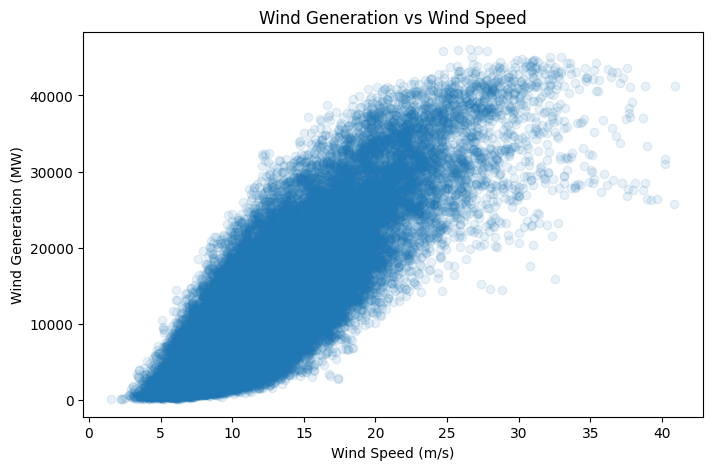

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    eda_df['wind_speed_ms'],
    eda_df['DE_wind_generation_actual'],
    alpha=0.1
)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Wind Generation (MW)')
plt.title('Wind Generation vs Wind Speed')

plt.show()

### Wind Generation vs Wind Speed

The scatter plot revealed a strong positive relationship between wind speed and wind generation, consistent with the correlation coefficient of **0.848**. As wind speed increases, wind generation rises substantially, confirming wind speed as the dominant weather driver of wind power production.

The relationship is clearly non-linear. Generation increases rapidly at moderate wind speeds and then begins to level off at higher wind speeds, suggesting the influence of installed capacity limits and turbine operating constraints.

A fan-shaped pattern is also observed, with greater variability at higher wind speeds. This may reflect changes in installed wind capacity over time, geographical differences in wind conditions, and operational factors affecting power output.

Overall, the results confirm that wind speed is the strongest weather-related predictor identified in this study.

## Weather Effects on Renewable Generation

Weather variables affect solar and wind generation in different ways. For solar generation, humidity (-0.609) and temperature (0.469) exhibited stronger relationships than cloud cover (-0.255), indicating that broader seasonal and atmospheric conditions influence solar output more strongly than cloud cover alone.

For wind generation, wind speed emerged as the dominant predictor, exhibiting a very strong positive correlation (0.848). The corresponding scatter plot confirmed a clear non-linear relationship between wind speed and power production.

These findings demonstrate that renewable generation is highly weather-dependent, with solar output primarily influenced by seasonal atmospheric conditions and wind generation largely controlled by wind speed.

### Renewable Integration Analysis

To evaluate the contribution of renewable energy to Germany's electricity system, solar and wind generation were combined into a single renewable generation metric. This enables assessment of renewable penetration, renewable share of electricity demand, and the ability of renewable resources to meet electricity consumption throughout the year.

In [35]:
eda_df['renewable_generation'] = (
    eda_df['DE_solar_generation_actual'] +
    eda_df['DE_wind_generation_actual']
)

eda_df[
    [
        'DE_solar_generation_actual',
        'DE_wind_generation_actual',
        'renewable_generation'
    ]
].head()

,DE_solar_generation_actual,DE_wind_generation_actual,renewable_generation
0,71.0,8852.0,8923.0
1,71.0,9054.0,9125.0
2,71.0,9070.0,9141.0
3,71.0,9163.0,9234.0
4,71.0,9231.0,9302.0


### Combined Renewable Generation

A new variable, **renewable_generation**, was created by summing solar and wind generation. This represents the total electricity supplied by the two major renewable energy sources in the dataset and provides a basis for evaluating renewable penetration and renewable contribution to electricity demand.

### Calculating Renewable Share of Demand

In [36]:
eda_df['renewable_share_pct'] = (
    eda_df['renewable_generation'] /
    eda_df['DE_load_actual_entsoe_transparency']
) * 100

eda_df['renewable_share_pct'].describe()

count    50400.000000
mean        28.953420
std         18.200884
min          0.500037
25%         14.333369
50%         25.901500
75%         40.268705
max         98.710884
Name: renewable_share_pct, dtype: float64

### Renewable Share of Electricity Demand

Renewable penetration was calculated as the percentage of electricity demand supplied by combined solar and wind generation.

The average renewable share of demand was **28.95%**, indicating that renewable energy supplied nearly one-third of Germany's electricity demand over the study period. However, renewable contribution varied substantially over time, with a standard deviation of **18.2%**.

The maximum observed renewable share reached **98.71%**, demonstrating that solar and wind generation were occasionally capable of meeting almost all electricity demand. These results highlight both the growing importance of renewable energy and the variability associated with weather-dependent generation sources.

### Monthly Renewable Share

In [37]:
monthly_renewable_share = (
    eda_df.groupby('month')
    ['renewable_share_pct']
    .mean()
)

monthly_renewable_share

month
1     29.221026
2     30.515001
3     31.852475
4     31.745972
5     30.227825
6     27.711909
7     27.178991
8     25.968473
9     26.305108
10    26.872615
11    25.909348
12    33.923628
Name: renewable_share_pct, dtype: float64

### Seasonal Renewable Penetration

Monthly renewable penetration analysis revealed that the average renewable share of electricity demand ranged from **25.9%** in November to **33.9%** in December.

Despite strong seasonal variations in solar and wind generation individually, the combined renewable share remained relatively stable throughout the year. This stability is largely attributable to the complementary nature of the two renewable resources: solar generation peaks during summer months, while wind generation peaks during winter months.

The results demonstrate that combining multiple renewable technologies can reduce seasonal variability and improve the consistency of renewable energy supply.

### Visualizing Monthly Renewable Share

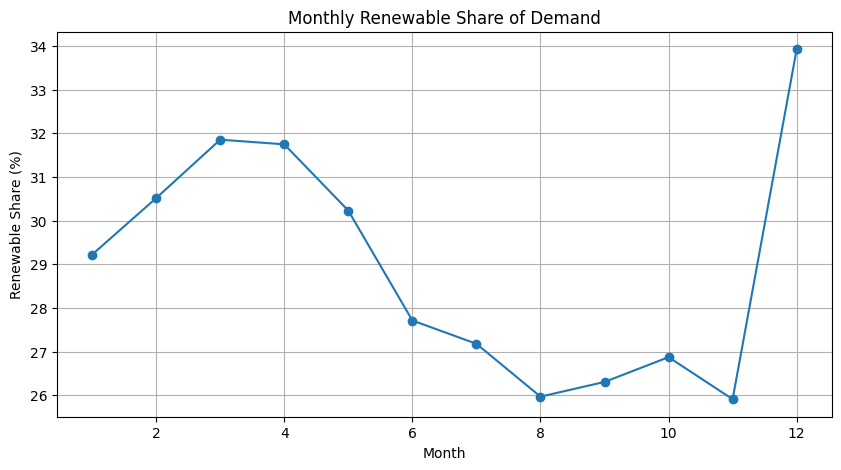

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_renewable_share.index,
    monthly_renewable_share.values,
    marker='o'
)

plt.title('Monthly Renewable Share of Demand')
plt.xlabel('Month')
plt.ylabel('Renewable Share (%)')
plt.grid(True)

plt.show()

### Monthly Renewable Share of Demand

The monthly renewable share of demand exhibited relatively limited seasonal variation, remaining between approximately 26% and 34% throughout the year. Compared with the strong seasonal fluctuations observed in individual solar and wind generation profiles, renewable penetration remained comparatively stable.

Renewable share peaked in December, largely due to high wind generation, while the lowest values occurred during late summer and autumn. Spring months also exhibited strong renewable penetration because both solar and wind generation contributed simultaneously.

The stability of the renewable share highlights the complementary seasonal behavior of solar and wind resources and demonstrates the value of a diversified renewable energy portfolio.

### Identifying High Renewable Penetration Hours

In [39]:
high_renewable = eda_df[
    eda_df['renewable_share_pct'] >= 50
]

len(high_renewable), len(high_renewable) / len(eda_df) * 100

(6957, 13.803571428571429)

### High Renewable Penetration Periods

To assess the extent of renewable integration, periods with renewable penetration greater than or equal to 50% were identified.

A total of **6,957 hours**, representing **13.8%** of all observations, exhibited renewable shares of at least 50%. This indicates that solar and wind generation frequently supplied a majority of Germany's electricity demand.

The result demonstrates the growing role of renewable energy within the German electricity system and highlights the ability of variable renewable resources to meet substantial portions of electricity demand during favorable operating conditions.

### Identifying Very High Renewable Penetration Hours

In [40]:
very_high_renewable = eda_df[
    eda_df['renewable_share_pct'] >= 75
]

len(very_high_renewable), len(very_high_renewable) / len(eda_df) * 100

(907, 1.7996031746031746)

### Very High Renewable Penetration Periods

Periods with renewable penetration greater than or equal to 75% were also examined.

A total of **907 hours**, corresponding to **1.8%** of all observations, exhibited renewable shares above 75%. These periods represent instances where solar and wind generation supplied the vast majority of Germany's electricity demand.

The occurrence of hundreds of such events demonstrates that very high renewable penetration is not merely an isolated phenomenon. Instead, favorable combinations of wind and solar conditions can enable renewable resources to satisfy most electricity demand for extended periods.

### Finding When These Events Occur

In [41]:
very_high_renewable['month'].value_counts().sort_index()

month
1      69
2     156
3     152
4     102
5      75
6      42
7      60
8      46
9      42
10     40
12    123
Name: count, dtype: int64

### Seasonal Distribution of Very High Renewable Penetration

The occurrence of renewable penetration above 75% was strongly seasonal. The largest number of high-renewable events occurred during February (156 hours), March (152 hours), December (123 hours), and April (102 hours).

These results suggest that very high renewable penetration is most likely during late winter and early spring, when strong wind generation coincides with increasing solar output. This seasonal overlap enables renewable resources to meet a large fraction of electricity demand.

Interestingly, no observations with renewable shares above 75% were recorded in November, highlighting the importance of having both strong wind and sufficient solar generation to achieve very high renewable penetration levels.

### Visualizing High-Renewable Events by Month

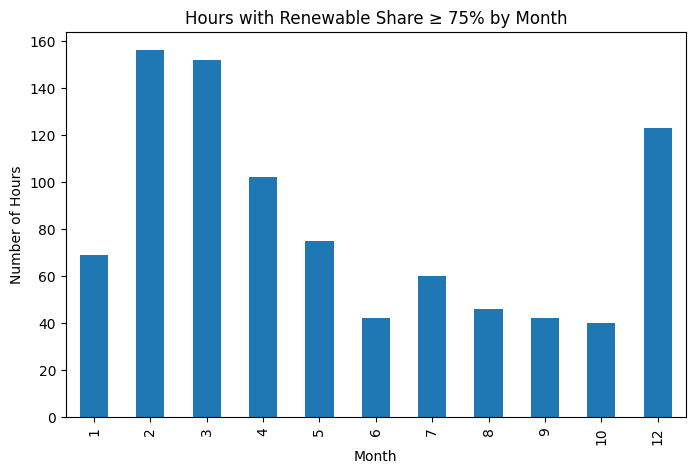

In [42]:
very_high_renewable['month'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Hours with Renewable Share ≥ 75% by Month')
plt.xlabel('Month')
plt.ylabel('Number of Hours')

plt.show()

### Monthly Distribution of Very High Renewable Penetration Events

The monthly distribution of renewable penetration events above 75% revealed a strong seasonal pattern. High-renewable events were concentrated primarily between February and April, with a secondary peak occurring in December.

This distribution supports the hypothesis that exceptionally high renewable penetration is most likely when strong winter wind resources coincide with increasing solar generation during the transition from winter to spring. The visual concentration of events in these months further demonstrates the complementary nature of Germany's renewable energy resources.

The results suggest that renewable integration benefits not only from individual resource availability but also from favorable seasonal overlap between different renewable technologies.

## Demand Forecasting-Oriented Analysis

The next phase of exploratory data analysis focuses on identifying variables that may be useful for electricity demand forecasting. Correlation analysis is used as an initial screening tool to evaluate the strength and direction of relationships between demand and potential predictor variables.

### Correlation of Features with Demand

In [43]:
demand_corr = eda_df.corr(numeric_only=True)[
    'DE_load_actual_entsoe_transparency'
].sort_values(ascending=False)

demand_corr

DE_load_actual_entsoe_transparency    1.000000
DE_LU_price_day_ahead                 0.486813
DE_solar_generation_actual            0.312084
renewable_generation                  0.298251
wind_speed_ms                         0.198945
hour                                  0.153393
cloud_cover_pct                       0.141674
DE_wind_generation_actual             0.103683
precipitation_mm                      0.036542
renewable_share_pct                   0.024058
DE_wind_capacity                     -0.003768
year                                 -0.015548
DE_solar_capacity                    -0.029736
week_of_year                         -0.063681
month                                -0.067005
quarter                              -0.067406
temperature_C                        -0.069806
humidity_pct                         -0.178599
day_of_week                          -0.398082
is_weekend                           -0.488242
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Correlation Analysis for Demand Forecasting

Correlation analysis was performed to identify variables that may be useful for electricity demand forecasting. The strongest positive relationship was observed between demand and day-ahead electricity price (0.487), reflecting the close interaction between market conditions and electricity consumption.

Among calendar variables, the weekend indicator (-0.488) and day of week (-0.398) exhibited strong negative correlations with demand, confirming the significant impact of human activity patterns on electricity consumption.

Weather-related variables generally showed weaker relationships with demand. Temperature displayed only a weak negative correlation (-0.070), suggesting that calendar effects and market dynamics may be more important predictors of demand than weather conditions in this dataset.

These findings provide an initial indication of which variables may contribute most effectively to future demand forecasting models.

### Investigating Demand by Day of Week

In [44]:
weekly_demand = (
    eda_df.groupby('day_of_week')
    ['DE_load_actual_entsoe_transparency']
    .mean()
)

weekly_demand

day_of_week
0    57522.666111
1    59241.186667
2    59454.877083
3    58964.440278
4    57742.414722
5    49619.239861
6    45902.455139
Name: DE_load_actual_entsoe_transparency, dtype: float64

### Weekly Demand Patterns

Electricity demand exhibits a pronounced weekly cycle. Average demand increases from Monday through Wednesday, reaching a peak of approximately **59,455 MW** on Wednesday before gradually declining toward the weekend.

The largest reduction occurs on Saturday and Sunday, when average demand falls to approximately **49,619 MW** and **45,902 MW**, respectively. The difference between the highest-demand day (Wednesday) and the lowest-demand day (Sunday) exceeds **13,500 MW**, corresponding to a reduction of approximately **23%**.

This strong weekly pattern confirms the importance of human activity and economic schedules in shaping electricity demand and suggests that calendar variables such as day of week and weekend indicators are likely to be valuable features for demand forecasting models.

### Visualizing Weekly Demand Pattern

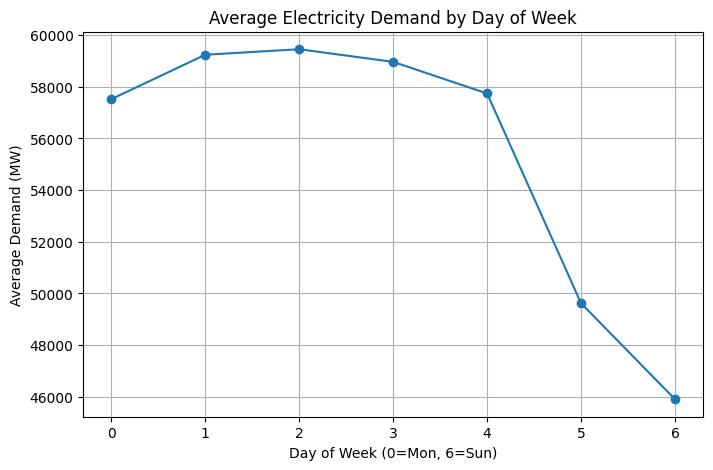

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    weekly_demand.index,
    weekly_demand.values,
    marker='o'
)

plt.title('Average Electricity Demand by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average Demand (MW)')
plt.grid(True)

plt.show()

### Weekly Demand Cycle Visualization

The weekly demand profile exhibits a clear and repeatable pattern. Demand rises from Monday and reaches a maximum during the middle of the week before declining toward the weekend.

A sharp reduction in demand occurs on Saturday, followed by the lowest demand levels on Sunday. This pattern reflects the influence of commercial and industrial activity on electricity consumption and highlights the importance of weekly calendar effects in demand forecasting.

The consistency of the weekly cycle suggests that calendar-based features are likely to provide substantial predictive value in machine learning models for electricity demand forecasting.

### Investigating Demand Persistence (Previous Hour Effect)

In [46]:
eda_df['load_lag_1'] = (
    eda_df['DE_load_actual_entsoe_transparency']
    .shift(1)
)

eda_df[
    [
        'DE_load_actual_entsoe_transparency',
        'load_lag_1'
    ]
].corr()

,DE_load_actual_entsoe_transparency,load_lag_1
DE_load_actual_entsoe_transparency,1.000000,0.966925
load_lag_1,0.966925,1.000000


### Demand Persistence: Previous-Hour Demand

To evaluate temporal persistence in electricity demand, a one-hour lag feature was created and compared with current demand.

The correlation between current demand and demand in the previous hour was **0.967**, representing the strongest relationship identified in the analysis. This result indicates that electricity demand changes gradually over time and exhibits a high degree of short-term persistence.

The strong relationship reflects the continuous nature of electricity consumption patterns, which are influenced by slowly changing human activities, industrial operations, and weather conditions. From a forecasting perspective, lagged demand variables are expected to be among the most informative predictors in machine learning models.

### Creating a Previous-Day Demand Feature

In [47]:
eda_df['load_lag_24'] = (
    eda_df['DE_load_actual_entsoe_transparency']
    .shift(24)
)

eda_df[
    [
        'DE_load_actual_entsoe_transparency',
        'load_lag_24'
    ]
].corr()

,DE_load_actual_entsoe_transparency,load_lag_24
DE_load_actual_entsoe_transparency,1.0000,0.7647
load_lag_24,0.7647,1.0000


### Demand Persistence: Previous-Day Demand

A 24-hour lag feature was created to evaluate the relationship between current electricity demand and demand observed at the same time on the previous day.

The correlation between current demand and previous-day demand was **0.765**, indicating a strong positive relationship. Although weaker than the one-hour lag correlation (0.967), the result demonstrates that daily demand patterns exhibit substantial repeatability.

The lower correlation reflects differences between weekdays and weekends, public holidays, weather conditions, and other factors that can cause demand patterns to vary from one day to the next. Nevertheless, previous-day demand remains a valuable candidate feature for electricity demand forecasting models.

### Demand Persistence: Previous-Week Demand

In [48]:
eda_df['load_lag_168'] = (
    eda_df['DE_load_actual_entsoe_transparency']
    .shift(168)
)

eda_df[
    [
        'DE_load_actual_entsoe_transparency',
        'load_lag_168'
    ]
].corr()

,DE_load_actual_entsoe_transparency,load_lag_168
DE_load_actual_entsoe_transparency,1.000000,0.913118
load_lag_168,0.913118,1.000000


### Demand Persistence: Previous-Week Demand

A 168-hour lag feature was created to evaluate the relationship between current electricity demand and demand observed at the same hour one week earlier.

The correlation between current demand and previous-week demand was **0.913**, indicating a very strong positive relationship. This correlation is substantially stronger than the previous-day demand correlation (0.765) and second only to the previous-hour demand correlation (0.967).

The result reflects the recurring weekly nature of electricity consumption patterns. Industrial activity, commercial operations, and human behavior often follow weekly schedules, causing demand at a given hour to resemble demand at the same hour one week earlier.

The strong weekly persistence suggests that lagged weekly demand is likely to be a highly informative feature for electricity demand forecasting models.

### Comparison of Lagged Demand Features

Three lagged demand features were evaluated to assess temporal persistence in electricity consumption patterns. Previous-hour demand exhibited the strongest relationship with current demand (0.967), followed by previous-week demand (0.913) and previous-day demand (0.765).

These results indicate that electricity demand is highly persistent and strongly influenced by recurring weekly patterns. The findings suggest that lagged demand variables are likely to be among the most valuable predictors in future machine learning models for demand forecasting.

## Correlation Heatmap of Forecasting Variables

To summarize relationships among key demand forecasting variables, a correlation heatmap was generated. Unlike previous analyses that examined relationships with demand individually, the heatmap provides a comprehensive view of how predictor variables relate to one another and to electricity demand.

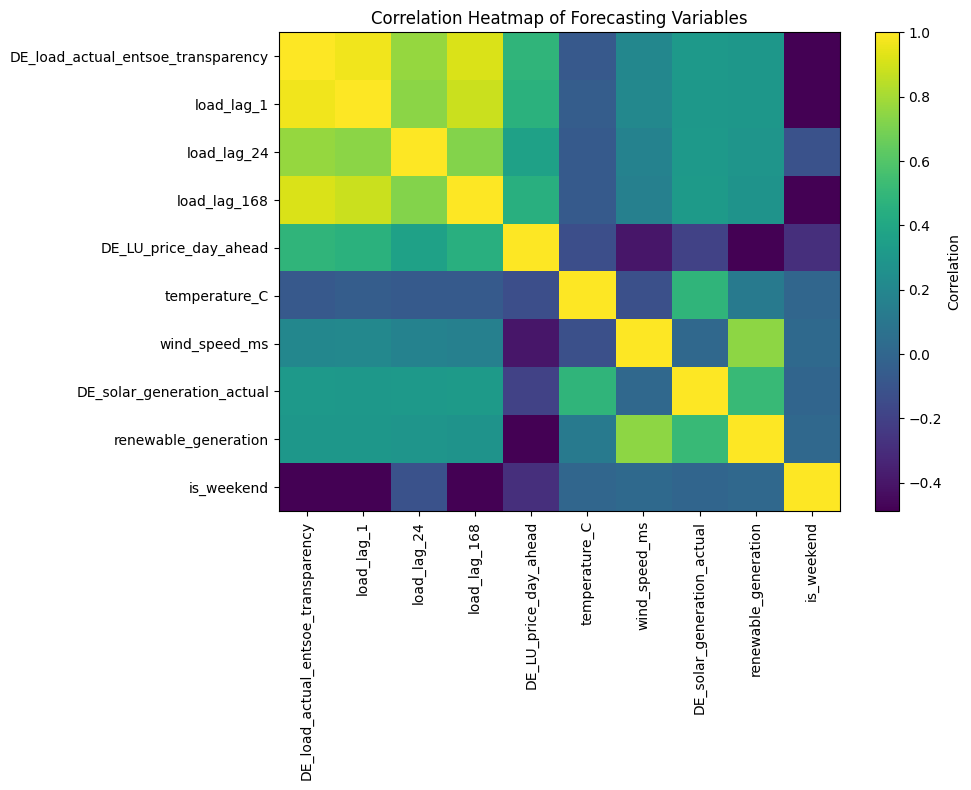

In [49]:
import matplotlib.pyplot as plt

corr_features = [
    'DE_load_actual_entsoe_transparency',
    'load_lag_1',
    'load_lag_24',
    'load_lag_168',
    'DE_LU_price_day_ahead',
    'temperature_C',
    'wind_speed_ms',
    'DE_solar_generation_actual',
    'renewable_generation',
    'is_weekend'
]

corr_matrix = eda_df[corr_features].corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Heatmap of Forecasting Variables')

plt.tight_layout()
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap provides a comprehensive overview of relationships among key forecasting variables. Lagged demand features exhibited the strongest associations with current demand, with previous-hour demand (0.967), previous-week demand (0.913), and previous-day demand (0.765) showing particularly strong positive correlations.

The weekend indicator maintained a strong negative relationship with demand, highlighting the importance of weekly behavioral and economic cycles. Day-ahead electricity price also demonstrated a moderate positive correlation with demand, reflecting market responses to changing electricity consumption.

Weather variables generally displayed stronger relationships with renewable generation than with electricity demand itself. This observation suggests that weather conditions primarily influence renewable energy production, while demand is more strongly governed by temporal and behavioral factors.

Overall, the heatmap confirms that lagged demand variables and calendar-based features are likely to be the most informative predictors for future electricity demand forecasting models.